In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path

# plotting settings
%matplotlib inline
sc.settings.verbosity = 0  # less verbose output
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)

# Dictionary of the datasets to analyze
CURRENT_RUN = "human_brain_10k"  # Change this to switch datasets

DATASETS = {
    "human_brain_10k": {
        "rna_raw": "data/10k_Human_Brain_MO_gemx_filtered_feature_bc_matrix.h5",
        "title": "Human Brain 10k (Multiome)"
    },
    "lymphoma_14k": {
        "rna_raw": "data/lymph_node_lymphoma_14k_filtered_feature_bc_matrix.h5",
        "title": "Lymphoma 14k (Multiome)"
    }
}

/tmp/ipykernel_93247/1871815573.py:10: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)


🔍 Dataset analysis: Human Brain 10k (Multiome)


/home/mila/rustscenic-test/venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


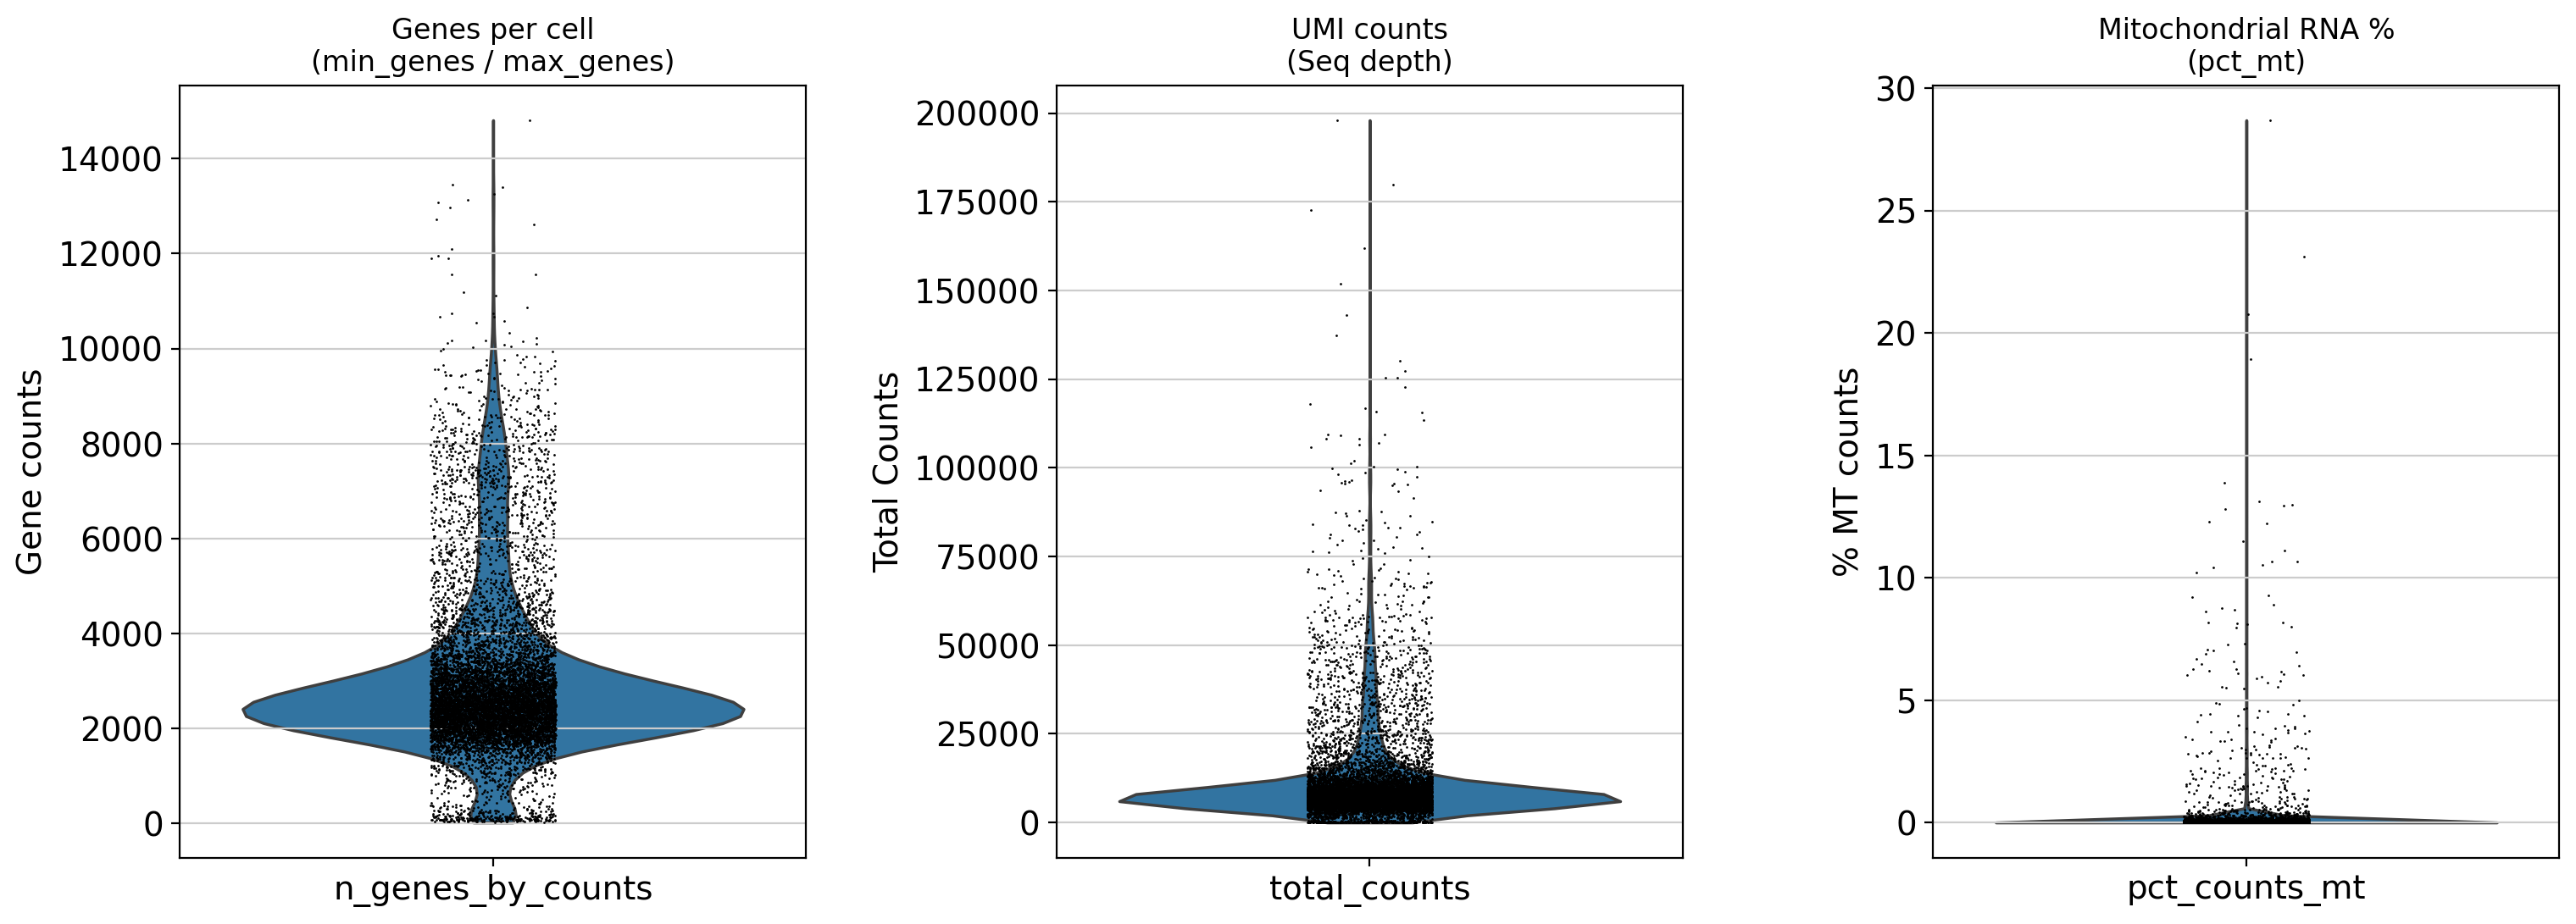


📊 Stats:


,Metrics,Values
0,Cell counts,10261
1,Gene counts,38606
2,Gene median,2555
3,UMI median,7403
4,MT% median,0.01%


In [2]:
def quick_qc_scan(dataset_id):
    config = DATASETS[dataset_id]
    path = Path(config["rna_raw"])
    
    if not path.exists():
        print(f"❌ Error: File not found: {path}")
        return

    print(f"🔍 Dataset analysis: {config['title']}")
    
    # 1. Loading data
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()

    # 2. Metrics calculation
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

    # 3. Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.subplots_adjust(wspace=0.4)

    # Genes per cell 
    sc.pl.violin(adata, "n_genes_by_counts", ax=axes[0], show=False, multi_panel=False)
    axes[0].set_title("Genes per cell\n(min_genes / max_genes)", fontsize=12)
    axes[0].set_ylabel("Gene counts")

    # UMI counts 
    sc.pl.violin(adata, "total_counts", ax=axes[1], show=False, multi_panel=False)
    axes[1].set_title("UMI counts\n(Seq depth)", fontsize=12)
    axes[1].set_ylabel("Total Counts")

    # Mitochondrial percentage 
    sc.pl.violin(adata, "pct_counts_mt", ax=axes[2], show=False, multi_panel=False)
    axes[2].set_title("Mitochondrial RNA %\n(pct_mt)", fontsize=12)
    axes[2].set_ylabel("% MT counts")

    plt.show()

    # 4. Table summary
    stats = pd.DataFrame({
        "Metrics": ["Cell counts", "Gene counts", "Gene median", "UMI median", "MT% median"],
        "Values": [
            adata.n_obs,
            adata.n_vars,
            int(adata.obs['n_genes_by_counts'].median()),
            int(adata.obs['total_counts'].median()),
            f"{adata.obs['pct_counts_mt'].median():.2f}%"
        ]
    })
    
    print("\n📊 Stats:")
    display(stats) 

quick_qc_scan(CURRENT_RUN)